# Personal Finance Analyser — Visualisations

## Overview
This notebook creates polished visualisations from the cleaned and analysed data.

## Charts
1. Monthly income vs expenses (bar chart)
2. Spending by category (donut chart)
3. Daily spending with rolling average (line chart)
4. Month on month spending change (bar chart)
5. 3 month spending projection (line chart)

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# Load the analysis datasets
monthly_summary = pd.read_csv('../data/monthly_summary.csv')
category_breakdown = pd.read_csv('../data/category_breakdown.csv')
daily_expenses = pd.read_csv('../data/daily_expenses.csv', parse_dates=['date'])

# Set the visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Libraries and data loaded successfully")

Libraries and data loaded successfully


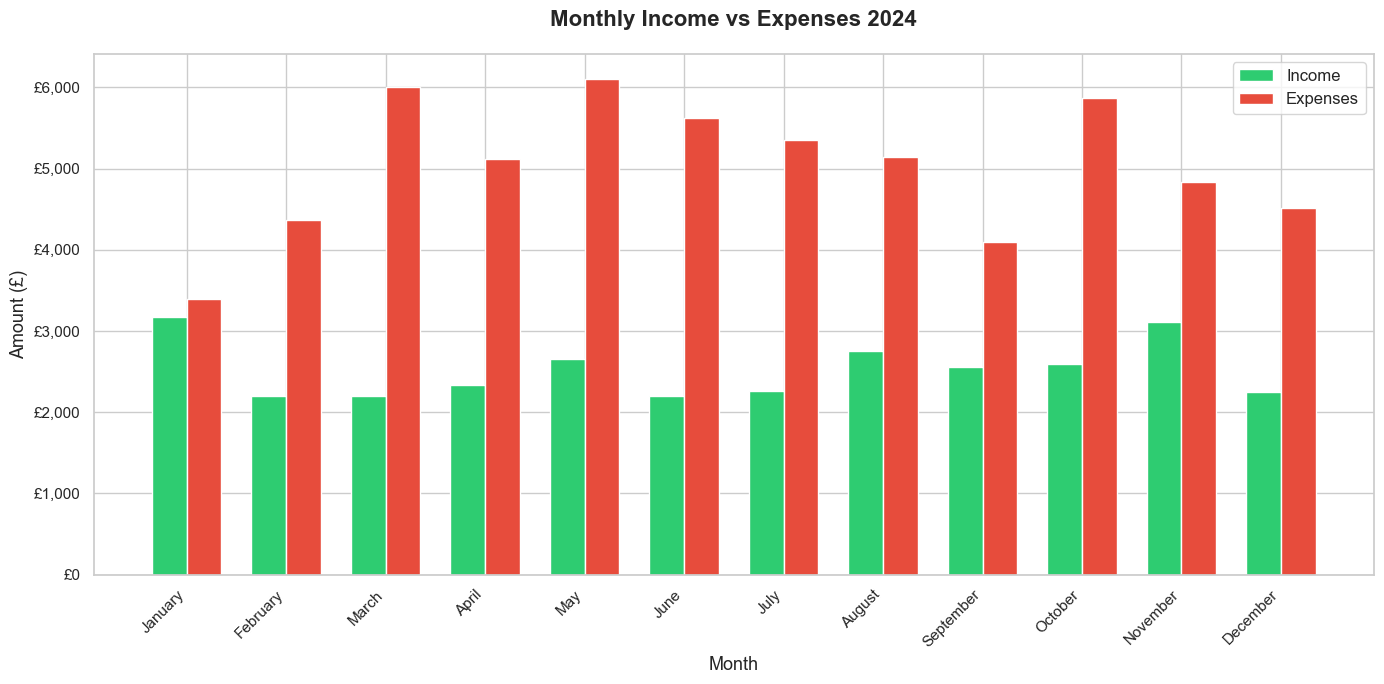

Chart 1 saved


In [2]:
# Chart 1 - Monthly income vs expenses
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(monthly_summary['month_name']))
width = 0.35

bars1 = ax.bar(x - width/2, monthly_summary['total_income'], width, 
               label='Income', color='#2ecc71', edgecolor='white')
bars2 = ax.bar(x + width/2, monthly_summary['total_spent'], width, 
               label='Expenses', color='#e74c3c', edgecolor='white')

ax.set_xlabel('Month', fontsize=13)
ax.set_ylabel('Amount (£)', fontsize=13)
ax.set_title('Monthly Income vs Expenses 2024', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(monthly_summary['month_name'], rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'£{x:,.0f}'))
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('../visualisations/01_monthly_income_vs_expenses.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved")

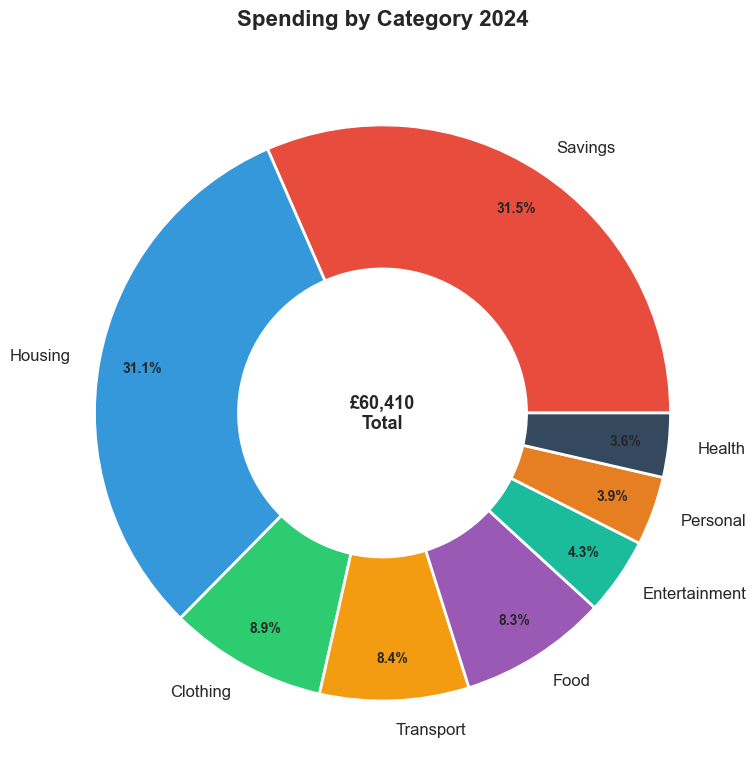

Chart 2 saved


In [3]:
# Chart 2 - Spending by category donut chart
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', 
          '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

wedges, texts, autotexts = ax.pie(
    category_breakdown['total_spent'],
    labels=category_breakdown['category'],
    autopct='%1.1f%%',
    colors=colors,
    pctdistance=0.85,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)

for text in texts:
    text.set_fontsize(12)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

ax.set_title('Spending by Category 2024', fontsize=16, fontweight='bold', pad=20)

centre_circle = plt.Circle((0, 0), 0.35, fc='white')
ax.add_patch(centre_circle)

total = category_breakdown['total_spent'].sum()
ax.text(0, 0, f'£{total:,.0f}\nTotal', ha='center', va='center', 
        fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../visualisations/02_spending_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved")

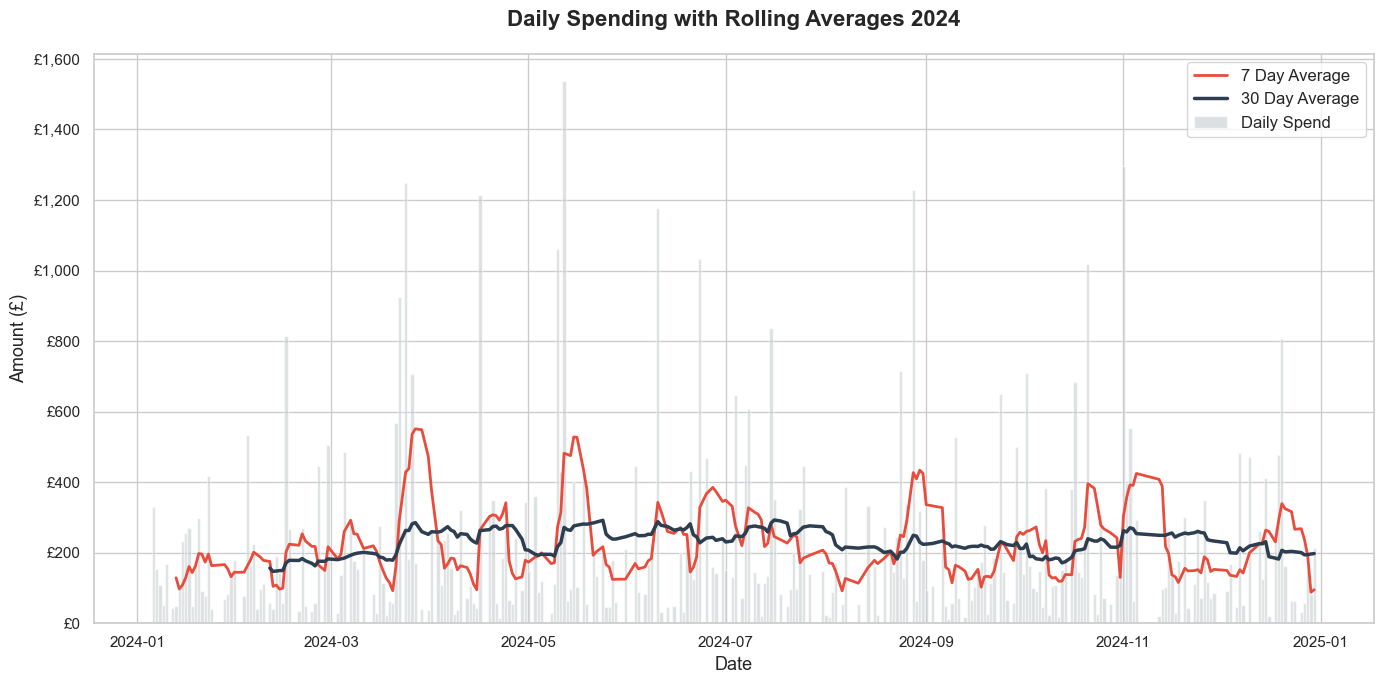

Chart 3 saved


In [4]:
# Chart 3 - Daily spending with rolling averages
fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(daily_expenses['date'], daily_expenses['daily_total'], 
       color='#bdc3c7', alpha=0.5, label='Daily Spend', width=1)

ax.plot(daily_expenses['date'], daily_expenses['rolling_7day'], 
        color='#e74c3c', linewidth=2, label='7 Day Average')

ax.plot(daily_expenses['date'], daily_expenses['rolling_30day'], 
        color='#2c3e50', linewidth=2.5, label='30 Day Average')

ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Amount (£)', fontsize=13)
ax.set_title('Daily Spending with Rolling Averages 2024', fontsize=16, fontweight='bold', pad=20)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'£{x:,.0f}'))
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('../visualisations/03_daily_spending_rolling_average.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved")

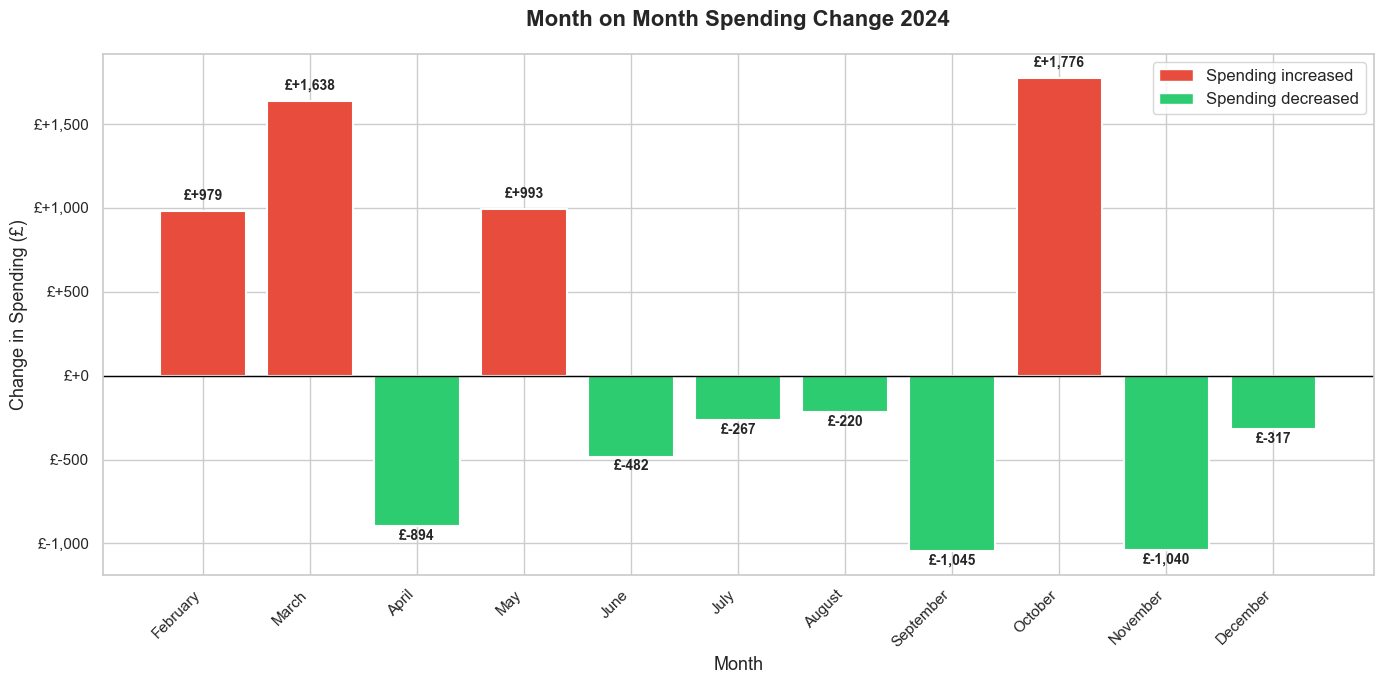

Chart 4 saved


In [6]:
# Chart 4 redone - with clear legend explaining colours
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.bar(monthly_mom['month_name'], monthly_mom['mom_change'], 
              color=colors, edgecolor='white', linewidth=1.5)

ax.axhline(y=0, color='black', linewidth=1, linestyle='-')
ax.set_xlabel('Month', fontsize=13)
ax.set_ylabel('Change in Spending (£)', fontsize=13)
ax.set_title('Month on Month Spending Change 2024', fontsize=16, fontweight='bold', pad=20)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'£{x:+,.0f}'))

for bar, value in zip(bars, monthly_mom['mom_change']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (50 if value >= 0 else -100),
            f'£{value:+,.0f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

legend_elements = [Patch(facecolor='#e74c3c', label='Spending increased'),
                   Patch(facecolor='#2ecc71', label='Spending decreased')]
ax.legend(handles=legend_elements, fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../visualisations/04_month_on_month_change.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved")

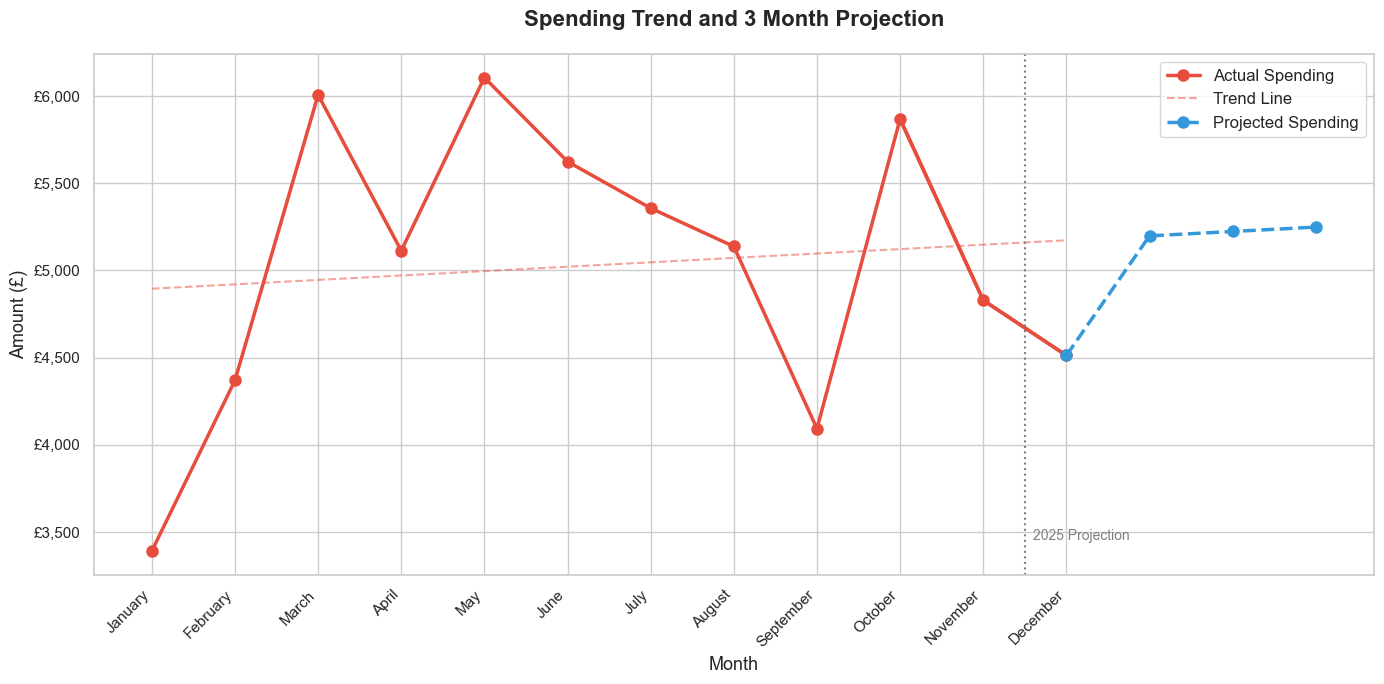

Chart 5 saved


In [7]:
# Chart 5 - Spending projection
months_2024 = monthly_summary['month'].values
spent_2024 = monthly_summary['total_spent'].values

# Fit linear trend
coefficients = np.polyfit(months_2024, spent_2024, 1)
slope = coefficients[0]
intercept = coefficients[1]

# Project 3 months ahead
future_months = np.array([13, 14, 15])
projected_spent = slope * future_months + intercept
future_labels = ['Jan 2025', 'Feb 2025', 'Mar 2025']

fig, ax = plt.subplots(figsize=(14, 7))

# Plot actual spending
ax.plot(monthly_summary['month_name'], spent_2024, 
        color='#e74c3c', linewidth=2.5, marker='o', markersize=8, label='Actual Spending')

# Plot trend line across 2024
trend_line = slope * months_2024 + intercept
ax.plot(monthly_summary['month_name'], trend_line,
        color='#e74c3c', linewidth=1.5, linestyle='--', alpha=0.5, label='Trend Line')

# Plot projections
all_labels = list(monthly_summary['month_name']) + future_labels
proj_x = list(range(12, 15))
ax.plot(range(9, 12), spent_2024[-3:], color='#e74c3c', linewidth=2.5)
ax.plot([11, 12, 13, 14], 
        [spent_2024[-1]] + list(projected_spent),
        color='#3498db', linewidth=2.5, marker='o', markersize=8,
        linestyle='--', label='Projected Spending')

ax.set_xlabel('Month', fontsize=13)
ax.set_ylabel('Amount (£)', fontsize=13)
ax.set_title('Spending Trend and 3 Month Projection', fontsize=16, fontweight='bold', pad=20)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'£{x:,.0f}'))

tick_positions = list(range(12))
tick_labels = list(monthly_summary['month_name'])
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')
ax.legend(fontsize=12)
ax.axvline(x=10.5, color='grey', linestyle=':', linewidth=1.5)
ax.text(10.6, ax.get_ylim()[0] + 200, '2025 Projection', fontsize=10, color='grey')

plt.tight_layout()
plt.savefig('../visualisations/05_spending_projection.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved")